# **Northwind Sales Performance Analysis**
### *Business Question: What drives revenue, and how can we improve performance?*

# **Imports Libraries & Intial Setup** 

In [133]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_columns = None

# **Load Data & Overview**

In [134]:
df_raw = pd.read_csv('sales_data.csv', encoding='latin1')
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2161 entries, 0 to 2160
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      2158 non-null   float64
 1   FirstName       2158 non-null   object 
 2   LastName        2158 non-null   object 
 3   City            2158 non-null   object 
 4   Country         2158 non-null   object 
 5   Phone           2158 non-null   object 
 6   OrderID         2155 non-null   float64
 7   OrderDate       2155 non-null   object 
 8   OrderNumber     2155 non-null   float64
 9   TotalAmount     2155 non-null   float64
 10  ProductID       2157 non-null   float64
 11  ProductName     2157 non-null   object 
 12  UnitPrice       2157 non-null   float64
 13  Package         2157 non-null   object 
 14  IsDiscontinued  2157 non-null   object 
 15  SupplierID      2157 non-null   float64
 16  CompanyName     2157 non-null   object 
 17  ContactName     2157 non-null   o

In [135]:
df_raw.head()

,CustomerID,FirstName,LastName,City,Country,Phone,OrderID,OrderDate,OrderNumber,TotalAmount,ProductID,ProductName,UnitPrice,Package,IsDiscontinued,SupplierID,CompanyName,ContactName,City.1,Country.1,Phone.1,Fax
0,85.00,Paul,Henriot,Reims,France,26.47.15.10,1.00,7/4/2012 0:00,"542,378.00",440.00,11.00,Queso Cabrales,21.00,1 kg pkg.,False,5.00,Cooperativa de Quesos 'Las Cabras',Antonio del Valle Saavedra,Oviedo,Spain,(98) 598 76 54,NaN
1,85.00,Paul,Henriot,Reims,France,26.47.15.10,1.00,7/4/2012 0:00,"542,378.00",440.00,42.00,Singaporean Hokkien Fried Mee,14.00,32 - 1 kg pkgs.,True,20.00,Leka Trading,Chandra Leka,Singapore,Singapore,555-8787,NaN
2,85.00,Paul,Henriot,Reims,France,26.47.15.10,1.00,7/4/2012 0:00,"542,378.00",440.00,72.00,Mozzarella di Giovanni,34.80,24 - 200 g pkgs.,False,14.00,Formaggi Fortini s.r.l.,Elio Rossi,Ravenna,Italy,(0544) 60323,(0544) 60603
3,79.00,Karin,Josephs,Münster,Germany,0251-031259,2.00,7/5/2012 0:00,"542,379.00","1,863.40",14.00,Tofu,23.25,40 - 100 g pkgs.,False,6.00,Mayumi's,Mayumi Ohno,Osaka,Japan,(06) 431-7877,NaN
4,79.00,Karin,Josephs,Münster,Germany,0251-031259,2.00,7/5/2012 0:00,"542,379.00","1,863.40",51.00,Manjimup Dried Apples,53.00,50 - 300 g pkgs.,False,24.00,"G'day, Mate",Wendy Mackenzie,Sydney,Australia,(02) 555-5914,(02) 555-4873


# **Data Cleaning**

In [136]:
df = df_raw.copy()

In [137]:
# Standardize column names
df.columns = df.columns.str.lower().str.strip()

In [138]:
df.columns

Index(['customerid', 'firstname', 'lastname', 'city', 'country', 'phone',
       'orderid', 'orderdate', 'ordernumber', 'totalamount', 'productid',
       'productname', 'unitprice', 'package', 'isdiscontinued', 'supplierid',
       'companyname', 'contactname', 'city.1', 'country.1', 'phone.1', 'fax'],
      dtype='object')

In [139]:
# Rename ambiguous columns
df.rename(columns={
    'city.1': 'supplier_city',
    'country.1': 'supplier_country',
    'phone.1': 'supplier_phone'
}, inplace=True)

In [140]:
# Fill missing fax with 'N/A'
df['fax'] = df['fax'].fillna('N/A')

In [141]:
# Drop rows missing critical fields
df.dropna(subset=['customerid', 'orderid', 'orderdate', 'totalamount', 'productid', 'productname'], inplace=True)

In [142]:
# Convert types
df['orderdate'] = pd.to_datetime(df['orderdate'])

In [143]:
# Convert types
id_cols = [c for c in df.columns if 'id' in c or 'ordernumber' in c]
for col in id_cols:
    df[col] = df[col].astype(int)

In [144]:
df['customer_name'] = df['firstname'] + ' ' + df['lastname']

In [145]:
df.customer_name.replace({ 
    'Carlos Gonz?lez': 'Carlos Gonzalez',
    'Guillermo Fern?ndez': 'Guillermo Fernandez',
    'Mart?n Sommer': 'Martin Sommer',
    'L?cia Carvalho': 'Lcia Carvalho',
},inplace=True)

In [146]:
df.city.replace({
    'San Crist?bal': 'San Cristóbal',
    'K?ln': 'Köln',
    'Br?cke': 'Brücken',
    'Lule?': 'Luleå',
    '?rhus': 'Århus'
}, inplace= True)

In [147]:
df.productname.replace({
    "Gustaf's Kn?ckebr?d": "Gustaf's Knäckebröd",
    'Guaran? Fant?stica': 'Guaraná Fantástica',
    'Original Frankfurter grüne So?e': 'Original Frankfurter grüne Sosse',
    'Lakkalik??ri': 'Lakkalikööri',
    'R?ssle Sauerkraut': 'Rüssle Sauerkraut',
    'R?d Kaviar': 'Rød Kaviar',
    'Rh?nbr?u Klosterbier': 'Rhönbräu Klosterbier',
    'Wimmers gute Semmelkn?del': 'Wimmers gute Semmelknödel',
    'NuNuCa Nu?-Nougat-Creme': 'NuNuCa Nuß-Nougat-Creme',
    'Gumb?r Gummib?rchen': 'Gummibärchen',
    'Tunnbr?d': 'Tunnbrød'
}, inplace=True)

In [148]:
df.companyname.replace({
    'Formaggi Fortini s.r.l.': 'Formaggi Fortini s.r.l',
    'PB Kn?ckebr?d AB': 'PB Knäckebröd AB',
    'Pasta Buttini s.r.l.': 'Pasta Buttini s.r.l',
    'Svensk Sj?f?da AB': 'Svensk Sjöfärda AB',
    'Plutzer Lebensmittelgro?m?rkte AG': 'Plutzer Lebensmittelgroßmärkte AG',
    'Heli Sü?waren GmbH & Co. KG': 'Heli Süßwaren GmbH & Co-KG'
}, inplace= True)

In [149]:
print(f"\n Clean Dataset Shape: {df.shape}")
print(f"Date range: {df['orderdate'].min().date()} → {df['orderdate'].max().date()}")
print(f"Null values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


 Clean Dataset Shape: (2155, 23)
Date range: 2012-07-04 → 2014-05-06
Null values:
Series([], dtype: int64)


In [150]:
# Fix Total Amount Double-Counting
# TotalAmount is repeated for each product in the same order — must deduplicate
# at order level before any revenue calculation
orders_df = df.drop_duplicates(subset='orderid')[['orderid', 'orderdate', 'customerid', 'customer_name', 'city', 'country', 'totalamount']].copy()

In [151]:
orders_df['year']  = orders_df['orderdate'].dt.year
orders_df['month'] = orders_df['orderdate'].dt.to_period('M')
orders_df['month_dt'] = orders_df['orderdate'].dt.to_period('M').dt.to_timestamp()

In [152]:
# Order-Level Dataset
print(f"Unique orders: {orders_df['orderid'].nunique()}")
print(f"Total revenue (corrected): ${orders_df['totalamount'].sum():,.2f}")

Unique orders: 830
Total revenue (corrected): $1,354,458.59


# **EDA** 

## **Descriptive Statistics**

In [153]:
# Revenue per Order (Summary)
print(orders_df['totalamount'].describe())

# Unit Price (Summary)
print(df['unitprice'].describe())

count      830.00
mean     1,631.88
std      1,990.61
min         12.50
25%        480.00
50%      1,015.90
75%      2,028.65
max     17,250.00
Name: totalamount, dtype: float64
count   2,155.00
mean       27.95
std        31.61
min         2.50
25%        12.50
50%        19.45
75%        34.00
max       263.50
Name: unitprice, dtype: float64


## **Distribution plots**

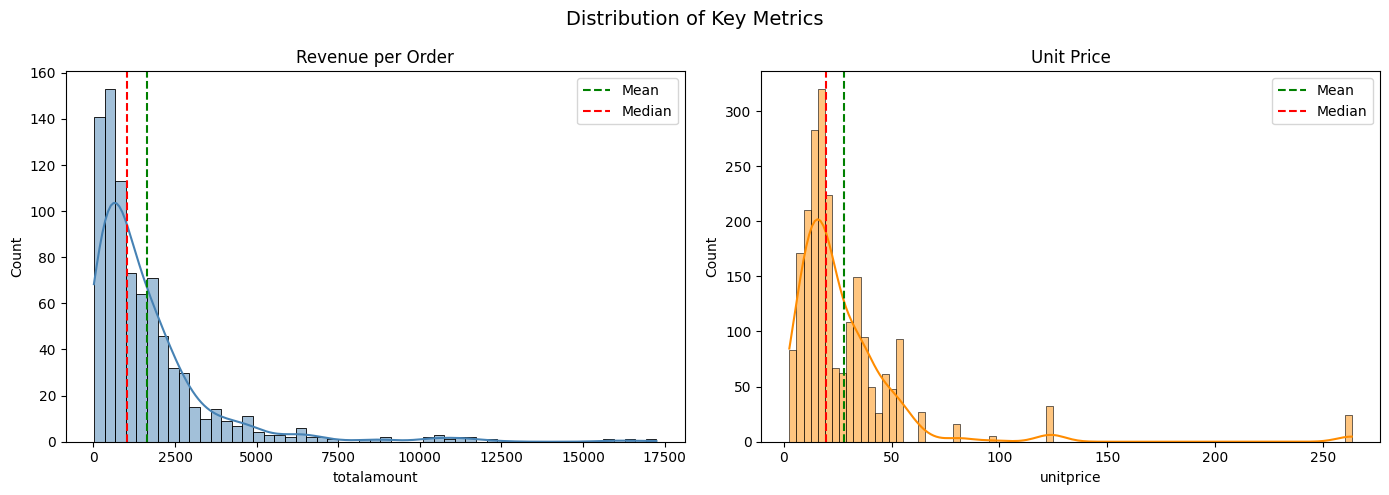

In [154]:
fig_dist, axes = plt.subplots(1, 2, figsize=(14, 5))
fig_dist.suptitle('Distribution of Key Metrics', fontsize=14)

sns.histplot(orders_df['totalamount'], kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(orders_df['totalamount'].mean(), color='green', linestyle='--', label='Mean')
axes[0].axvline(orders_df['totalamount'].median(), color='red', linestyle='--', label='Median')
axes[0].set_title('Revenue per Order')
axes[0].legend()

sns.histplot(df['unitprice'], kde=True, ax=axes[1], color='darkorange')
axes[1].axvline(df['unitprice'].mean(), color='green', linestyle='--', label='Mean')
axes[1].axvline(df['unitprice'].median(), color='red', linestyle='--', label='Median')
axes[1].set_title('Unit Price')
axes[1].legend()

plt.tight_layout()
plt.savefig('dist_plot.png', dpi=150)
plt.show()

## **Outlier detection**

In [155]:
def count_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return int(((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum())

print(f"\nOutliers — Revenue per Order : {count_outliers(orders_df['totalamount'])}")
print(f"Outliers — Unit Price        : {count_outliers(df['unitprice'])}")


Outliers — Revenue per Order : 56
Outliers — Unit Price        : 77


## **Geographical Analysis**

In [156]:
# Revenue by country
country_rev = orders_df.groupby('country', as_index=False)['totalamount'].sum().sort_values('totalamount', ascending=False)
country_rev['pct'] = (country_rev['totalamount'] / country_rev['totalamount'].sum() * 100).round(2)

print("\n Top 10 Countries by Revenue")
print(country_rev.head(10).to_string(index=False))

fig_country_bar = px.bar(
    country_rev.head(10),
    x='country', y='totalamount',
    text='pct',
    title='Top 10 Countries by Revenue',
    labels={'totalamount': 'Total Revenue ($)', 'country': 'Country'},
    color='totalamount',
    color_continuous_scale='Blues'
)
fig_country_bar.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig_country_bar.show()

fig_country_pie = px.pie(
    country_rev.head(10),
    names='country', values='totalamount',
    title='Revenue Share — Top 10 Countries'
)
fig_country_pie.show()


 Top 10 Countries by Revenue
  country  totalamount   pct
      USA   263,566.98 19.46
  Germany   244,640.63 18.06
  Austria   139,496.63 10.30
   Brazil   114,968.48  8.49
   France    85,498.76  6.31
Venezuela    60,814.89  4.49
       UK    60,616.51  4.48
   Sweden    59,523.70  4.39
  Ireland    57,317.39  4.23
   Canada    55,334.10  4.09


In [157]:
# Revenue by city (top 10)
city_rev = orders_df.groupby('city', as_index=False)['totalamount'].sum().sort_values('totalamount', ascending=False)

fig_city = px.bar(
    city_rev.head(10),
    x='city', y='totalamount',
    title='Top 10 Cities by Revenue',
    labels={'totalamount': 'Total Revenue ($)', 'city': 'City'},
    color='totalamount',
    color_continuous_scale='Oranges'
)
fig_city.show()


# **Time Series Analysis** 

In [158]:
# Monthly revenue
monthly = orders_df.groupby('month_dt', as_index=False).agg(revenue=('totalamount', 'sum'), num_orders=('orderid', 'count'))
monthly['mom_growth'] = monthly['revenue'].pct_change() * 100

fig_monthly = make_subplots(rows=2, cols=1, shared_xaxes=True, subplot_titles=('Monthly Revenue', 'Number of Orders'))

fig_monthly.add_trace(
    go.Scatter(x=monthly['month_dt'], y=monthly['revenue'],
               mode='lines+markers', name='Revenue', line=dict(color='steelblue')),
    row=1, col=1
)
fig_monthly.add_trace(
    go.Bar(x=monthly['month_dt'], y=monthly['num_orders'],
           name='Orders', marker_color='darkorange'),
    row=2, col=1
)
fig_monthly.update_layout(title='Monthly Revenue & Order Volume (2012–2014)')
fig_monthly.show()

In [159]:
# MoM growth
fig_growth = px.bar(
    monthly.dropna(subset=['mom_growth']),
    x='month_dt', y='mom_growth',
    title='Month-over-Month Revenue Growth (%)',
    labels={'month_dt': 'Month', 'mom_growth': 'MoM Growth (%)'},
    color='mom_growth',
    color_continuous_scale='RdYlGn'
)
fig_growth.add_hline(y=0, line_dash='dash', line_color='black')
fig_growth.show()

In [160]:
# Yearly comparison
yearly = orders_df.groupby('year', as_index=False).agg(revenue=('totalamount', 'sum'), num_orders=('orderid', 'count'))
yearly['yoy_growth'] = yearly['revenue'].pct_change() * 100

In [161]:
# Year-over-Year Revenue
print(yearly.to_string(index=False))

 year    revenue  num_orders  yoy_growth
 2012 226,298.50         152         NaN
 2013 658,388.75         408      190.94
 2014 469,771.34         270      -28.65


In [162]:
fig_yearly = px.bar(
    yearly, x='year', y='revenue',
    title='Annual Revenue (YoY)',
    text='revenue',
    labels={'revenue': 'Total Revenue ($)', 'year': 'Year'},
    color='revenue',
    color_continuous_scale='Teal'
)
fig_yearly.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig_yearly.show()

In [163]:
# Countries ordering per month
country_monthly = orders_df.groupby('month_dt')['country'].nunique().reset_index().rename(columns={'country': 'active_countries'})

fig_countries_monthly = px.line(
    country_monthly,
    x='month_dt', y='active_countries',
    title='Number of Countries Placing Orders Each Month',
    labels={'month_dt': 'Month', 'active_countries': 'Active Countries'},
    markers=True
)
fig_countries_monthly.show()

## **Customers Analysis**

In [164]:
# Top 10 customers by total revenue
cust_rev = orders_df.groupby(['customerid', 'customer_name'], as_index=False).agg(total_revenue=('totalamount', 'sum'), num_orders=('orderid', 'count')).sort_values('total_revenue', ascending=False)

# Customers by Revenue
print(cust_rev.head(10).to_string(index=False))

fig_cust = px.bar(
    cust_rev.head(10),
    x='customer_name', y='total_revenue',
    title='Top 10 Customers by Total Revenue',
    labels={'customer_name': 'Customer', 'total_revenue': 'Revenue ($)'},
    color='total_revenue',
    color_continuous_scale='Purples',
    text='num_orders'
)
fig_cust.update_traces(texttemplate='%{text} orders', textposition='outside')
fig_cust.show()

 customerid    customer_name  total_revenue  num_orders
         63      Horst Kloss     117,483.39          28
         71   Jose Pavarotti     115,673.39          31
         20    Roland Mendel     113,236.68          30
         37 Patricia McKenna      57,317.39          19
         65     Paula Wilson      52,245.90          18
         34     Mario Pontes      34,101.15          14
         24    Maria Larsson      32,555.55          19
         51   Jean Fresnière      32,203.90          13
         39    Philip Cramer      31,745.75          14
         62    Lcia Carvalho      30,226.10          13


In [165]:
# Average order value per customer (top 10)
cust_rev['avg_order_value'] = cust_rev['total_revenue'] / cust_rev['num_orders']

In [166]:
fig_aov = px.scatter(
    cust_rev.head(20),
    x='num_orders', y='avg_order_value',
    size='total_revenue',
    hover_name='customer_name',
    title='Customer Segmentation: Order Frequency vs Average Order Value',
    labels={'num_orders': 'Number of Orders', 'avg_order_value': 'Avg Order Value ($)'},
    color='total_revenue',
    color_continuous_scale='Viridis'
)
fig_aov.show()

## **Product Analysis**

In [167]:
# Product-level analysis uses full df (each row = one product in one order)
product_stats = (df.groupby('productname', as_index=False)
    .agg(
        times_ordered=('orderid', 'count'),
        avg_unit_price=('unitprice', 'mean'),
        is_discontinued=('isdiscontinued', lambda x: x.mode()[0])
    ).sort_values('times_ordered', ascending=False))

In [168]:
# Top 10 Most Ordered Products
product_stats.head(10).to_string(index=False)

fig_prod = px.bar(
    product_stats.head(15),
    x='productname', y='times_ordered',
    title='Top 15 Most Frequently Ordered Products',
    labels={'productname': 'Product', 'times_ordered': 'Times Ordered'},
    color='avg_unit_price',
    color_continuous_scale='Reds'
)
fig_prod.update_layout(xaxis_tickangle=-40)
fig_prod.show()

In [169]:
# Discontinued products still being ordered
discontinued = df[df['isdiscontinued'] == 'True']['productname'].value_counts().reset_index()
discontinued.columns = ['product', 'order_count']

In [170]:
print(f"\n Discontinued Products Still Ordered: {len(discontinued)}")
print(discontinued.head(10).to_string(index=False))

if not discontinued.empty:
    fig_disc = px.bar(
        discontinued.head(10),
        x='product', y='order_count',
        title='Discontinued Products Still Being Ordered',
        labels={'product': 'Product', 'order_count': 'Orders'},
        color='order_count',
        color_continuous_scale='OrRd'
    )
    fig_disc.update_layout(xaxis_tickangle=-30)
    fig_disc.show()


 Discontinued Products Still Ordered: 0
Empty DataFrame
Columns: [product, order_count]
Index: []


## **Supplier Analysis**

In [171]:
supplier_stats = (df.groupby(['supplierid', 'companyname', 'supplier_country'], as_index=False)
    .agg(
        products_supplied=('productname', 'nunique'),
        total_orders=('orderid', 'count')
    ).sort_values('total_orders', ascending=False))

In [172]:
# Top 10 Suppliers by Order Volume
print(supplier_stats.head(10).to_string(index=False))

fig_sup = px.bar(
    supplier_stats.head(10),
    x='companyname', y='total_orders',
    title='Top 10 Suppliers by Order Volume',
    labels={'companyname': 'Supplier', 'total_orders': 'Total Orders'},
    color='products_supplied',
    color_continuous_scale='Greens',
    text='supplier_country'
)
fig_sup.update_layout(xaxis_tickangle=-30)
fig_sup.show()

 supplierid                       companyname supplier_country  products_supplied  total_orders
         12 Plutzer Lebensmittelgroßmärkte AG          Germany                  5           179
          7                     Pavlova, Ltd.        Australia                  5           163
          8          Specialty Biscuits, Ltd.               UK                  4           126
         15                   Norske Meierier           Norway                  3           105
         28                      Gai pâturage           France                  2           105
         14            Formaggi Fortini s.r.l            Italy                  3           104
         24                       G'day, Mate        Australia                  3            98
          1                    Exotic Liquids               UK                  3            94
         19       New England Seafood Cannery              USA                  2            88
         20                      Leka Tr

# **KEY INSIGHTS SUMMARY**

In [173]:
total_revenue   = orders_df['totalamount'].sum()
total_orders    = orders_df['orderid'].nunique()
total_customers = orders_df['customerid'].nunique()
total_products  = df['productname'].nunique()
avg_order_val   = orders_df['totalamount'].mean()
top_country     = country_rev.iloc[0]['country']
top_customer    = cust_rev.iloc[0]['customer_name']
top_product     = product_stats.iloc[0]['productname']
yoy_2013        = yearly[yearly['year'] == 2013]['yoy_growth'].values[0]
yoy_2014        = yearly[yearly['year'] == 2014]['yoy_growth'].values[0]

In [174]:
print("\n" + "="*50)
print("       KEY BUSINESS INSIGHTS SUMMARY")
print("="*50)
print(f"  Total Revenue (Corrected) : ${total_revenue:>12,.2f}")
print(f"  Total Orders              : {total_orders:>12,}")
print(f"  Unique Customers          : {total_customers:>12,}")
print(f"  Unique Products           : {total_products:>12,}")
print(f"  Average Order Value       : ${avg_order_val:>12,.2f}")
print(f"  Top Country               : {top_country}")
print(f"  Top Customer              : {top_customer}")
print(f"  Top Product (by orders)   : {top_product}")
print(f"  YoY Growth 2012→2013      : {yoy_2013:>+.1f}%")
print(f"  YoY Growth 2013→2014      : {yoy_2014:>+.1f}%")
print(f"  Discontinued Still Ordered: {len(discontinued)} products")
print("="*50)



       KEY BUSINESS INSIGHTS SUMMARY
  Total Revenue (Corrected) : $1,354,458.59
  Total Orders              :          830
  Unique Customers          :           89
  Unique Products           :           77
  Average Order Value       : $    1,631.88
  Top Country               : USA
  Top Customer              : Horst Kloss
  Top Product (by orders)   : Raclette Courdavault
  YoY Growth 2012→2013      : +190.9%
  YoY Growth 2013→2014      : -28.6%
  Discontinued Still Ordered: 0 products
